In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import nbaide

In [24]:
nbaide.install()

In [25]:
df = pd.read_csv("hf://datasets/HenryWaltson/TMDB-IMDB-Movies-Dataset/TMDB  IMDB Movies Dataset.csv")

df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,genres,production_companies,production_countries,spoken_languages,keywords,directors,writers,averageRating,numVotes,cast
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc...",Christopher Nolan,Christopher Nolan,8.8,2770171,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,...",Christopher Nolan,"Jonathan Nolan, Christopher Nolan",8.7,2456592,"Matthew McConaughey, Anne Hathaway, Michael Ca..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f...",Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Go...",9.1,3116358,"Christian Bale, Heath Ledger, Aaron Eckhart, M..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ...",James Cameron,James Cameron,7.9,1472421,"Sam Worthington, Zoe Saldaña, Sigourney Weaver..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com...",Joss Whedon,"Joss Whedon, Zak Penn",8.0,1539740,"Robert Downey Jr., Chris Evans, Mark Ruffalo, ..."


## Exploration du Dataset ##

The Dataset was found on [HuggingFace](https://huggingface.co/datasets/HenryWaltson/TMDB-IMDB-Movies-Dataset).
It is composed of TMDB and IMDB movies data.

In [26]:
print(f"The dataset contains {df.shape[0]} rows and {df.shape[1]} columns")

The dataset contains 434803 rows and 29 columns


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 434803 entries, 0 to 434802
Data columns (total 29 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    434803 non-null  int64  
 1   title                 434803 non-null  str    
 2   vote_average          434803 non-null  float64
 3   vote_count            434803 non-null  int64  
 4   status                434803 non-null  str    
 5   release_date          414261 non-null  str    
 6   revenue               434803 non-null  int64  
 7   runtime               434803 non-null  int64  
 8   adult                 434803 non-null  bool   
 9   backdrop_path         184870 non-null  str    
 10  budget                434803 non-null  int64  
 11  homepage              54526 non-null   str    
 12  tconst                434803 non-null  str    
 13  original_language     434803 non-null  str    
 14  original_title        434803 non-null  str    
 15  overview   

### Nettoyage des données

In [28]:
df = df.drop_duplicates()

In [29]:
df = df.drop(columns=['backdrop_path', 'keywords', 'homepage', 'tconst', 'overview', 'poster_path', 'tagline'])

In [30]:
df = df[df['release_date'].notna()]

### Feature Engineering

In [31]:
# Feature 1: Rating combiné pondéré
total_votes = df['vote_count'] + df['numVotes']
combined_rating = (df['vote_average'] * df['vote_count'] + df['averageRating'] * df['numVotes']) / total_votes

df['rating'] = combined_rating
df['total_votes'] = total_votes

In [32]:
df = df.drop(columns=['vote_count', 'numVotes', 'vote_average', 'averageRating'])
df.head()

,id,title,status,release_date,revenue,runtime,adult,budget,original_language,original_title,popularity,genres,production_companies,production_countries,spoken_languages,directors,writers,cast,rating,total_votes
0,27205,Inception,Released,2010-07-15,825532764,148,False,160000000,en,Inception,83.952,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili",Christopher Nolan,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...",8.794638,2804666
1,157336,Interstellar,Released,2014-11-05,701729206,169,False,165000000,en,Interstellar,140.241,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,Christopher Nolan,"Jonathan Nolan, Christopher Nolan","Matthew McConaughey, Anne Hathaway, Michael Ca...",8.696297,2489163
2,155,The Dark Knight,Released,2008-07-16,1004558444,152,False,185000000,en,The Dark Knight,130.643,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin",Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Go...","Christian Bale, Heath Ledger, Aaron Eckhart, M...",9.094279,3146977
3,19995,Avatar,Released,2009-12-15,2923706026,162,False,237000000,en,Avatar,79.932,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish",James Cameron,James Cameron,"Sam Worthington, Zoe Saldaña, Sigourney Weaver...",7.893510,1502236
4,24428,The Avengers,Released,2012-04-25,1518815515,143,False,220000000,en,The Avengers,98.082,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian",Joss Whedon,"Joss Whedon, Zak Penn","Robert Downey Jr., Chris Evans, Mark Ruffalo, ...",7.994609,1568906


In [33]:
df['release_year'] = pd.to_datetime(df['release_date']).dt.year

In [34]:
# Feature engineering
df['is_english'] = (df['original_language'] == 'en').astype(int)
df['cast_count'] = df['cast'].fillna('').apply(lambda x: len(x.split(',')) if x else 0)
df['release_month'] = pd.to_datetime(df['release_date']).dt.month
df['release_year'] = pd.to_datetime(df['release_date']).dt.year
df['num_languages'] = df['spoken_languages'].fillna('').apply(lambda x: len(x.split(',')) if x else 0)
df['num_countries'] = df['production_countries'].fillna('').apply(lambda x: len(x.split(',')) if x else 0)

features = [
    'rating',
    'total_votes',
    'popularity',
    'runtime',
    'is_english',
    'cast_count',
    'release_month',
    'release_year',
    'num_languages',
    'num_countries',
]

### Focus on the Label : Genres

In [35]:
unique_genres = df['genres'].dropna().str.split(', ').explode().unique()
number_of_genre = len(unique_genres)

print(f"There is {number_of_genre} different genres, that are :", sorted(unique_genres))

There is 19 different genres, that are : ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']


In [36]:
single_genre_count = df[df['genres'].str.contains(',', na=True) == False].shape[0]
print(f"Number of rows with only one unique genre: {single_genre_count}")

Number of rows with only one unique genre: 185210


On va donc prendre les films avec plusieurs genres, mais en gardant le premier genre qui apprait

In [37]:
# Supprimer les films sans genre
df_clean = df[df['genres'].notna()].copy()
print(f"Films avec genres : {len(df_clean)} / {len(df)}")

# Extraire le premier genre
df_clean['genre'] = df_clean['genres'].str.split(',').str[0].str.strip()

# Distribution des genres
print("\n Distribution des genres :")
genre_counts = df_clean['genre'].value_counts()
print(genre_counts.head(20))

print(f"\n Total de genres uniques : {df_clean['genre'].nunique()}")

Films avec genres : 351298 / 414261

 Distribution des genres :
genre
Drama              95151
Comedy             62676
Documentary        54188
Animation          20382
Action             20179
Horror             19401
Thriller           11261
Romance            10952
Crime              10800
Music               7592
Adventure           6776
Family              5892
Science Fiction     4897
TV Movie            4539
Western             4166
Fantasy             4014
Mystery             3388
War                 2539
History             2505
Name: count, dtype: int64

 Total de genres uniques : 19


In [38]:
# Garder Animation, Horror, Drama
selected_genres = ['Animation', 'Horror', 'Drama']
df_final = df_clean[df_clean['genre'].isin(selected_genres)].copy()

print(f"Films gardés : {len(df_final)}")
print(f"Genres : {selected_genres}")
print("\n Distribution finale :")
print(df_final['genre'].value_counts())

Films gardés : 134934
Genres : ['Animation', 'Horror', 'Drama']

 Distribution finale :
genre
Drama        95151
Animation    20382
Horror       19401
Name: count, dtype: int64


### Rééquilibrage des classes (Undersampling)

In [39]:
# Undersampling : on plafonne chaque classe au niveau de la plus petite (Adventure = 576)
cap = df_final['genre'].value_counts().min()
print(f"Cap par classe : {cap}")

df_balanced = (
    df_final
    .groupby('genre', group_keys=False)
    .sample(n=cap, random_state=42)
)

print("\nDistribution après rééquilibrage :")
print(df_balanced['genre'].value_counts())
print(f"\nTotal : {len(df_balanced)} films")

Cap par classe : 19401

Distribution après rééquilibrage :
genre
Animation    19401
Drama        19401
Horror       19401
Name: count, dtype: int64

Total : 58203 films


In [40]:
X = df_balanced[features]
y = df_balanced['genre']

In [41]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler

continuous_features = ['rating', 'total_votes', 'popularity', 'runtime']
passthrough_features = ['is_english', 'cast_count', 'release_month', 'release_year', 'num_languages', 'num_countries']

preprocessor = ColumnTransformer([
    ('scale', RobustScaler(), continuous_features),
    ('pass', 'passthrough', passthrough_features)
])

# 1. Train/test split stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 2. Pipeline preprocessing + modèle
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GaussianNB())
])
pipeline.fit(X_train, y_train)

# 3. Évaluation
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   Animation       0.69      0.76      0.72      3880
       Drama       0.62      0.66      0.64      3880
      Horror       0.69      0.57      0.62      3881

    accuracy                           0.66     11641
   macro avg       0.66      0.66      0.66     11641
weighted avg       0.66      0.66      0.66     11641



In [42]:
model = pipeline.named_steps['model']
feature_names = continuous_features + passthrough_features

print("=" * 60)
print("PARAMÈTRES DU MODÈLE GAUSSIEN NAIVE BAYES")
print("=" * 60)

print("\n1. PROBABILITÉS A PRIORI P(classe):")
print("-" * 40)
for classe, proba in zip(model.classes_, model.class_prior_):
    print(f"   {classe:12s}: {proba:.4f} ({proba*100:.2f}%)")

print("\n2. MOYENNES (μ) PAR FEATURE ET CLASSE:")
print("-" * 40)
theta_df = pd.DataFrame(model.theta_, index=model.classes_, columns=feature_names)
print(theta_df.round(3))

print("\n3. VARIANCES (σ²) PAR FEATURE ET CLASSE:")
print("-" * 40)
var_df = pd.DataFrame(model.var_, index=model.classes_, columns=feature_names)
print(var_df.round(3))

PARAMÈTRES DU MODÈLE GAUSSIEN NAIVE BAYES

1. PROBABILITÉS A PRIORI P(classe):
----------------------------------------
   Animation   : 0.3333 (33.33%)
   Drama       : 0.3333 (33.33%)
   Horror      : 0.3333 (33.33%)

2. MOYENNES (μ) PAR FEATURE ET CLASSE:
----------------------------------------
           rating  total_votes  popularity  runtime  is_english  cast_count  \
Animation   0.195        5.800       1.353   -0.557       0.631       2.623   
Drama       0.115        6.467       0.967    0.075       0.362       7.601   
Horror     -0.611        8.931       1.965   -0.030       0.732       6.801   

           release_month  release_year  num_languages  num_countries  
Animation          5.972      1985.175          0.777          0.937  
Drama              6.320      1993.888          1.042          1.051  
Horror             6.433      2006.111          0.905          0.865  

3. VARIANCES (σ²) PAR FEATURE ET CLASSE:
----------------------------------------
           ratin

## Étape 5 — Évaluation complète des performances

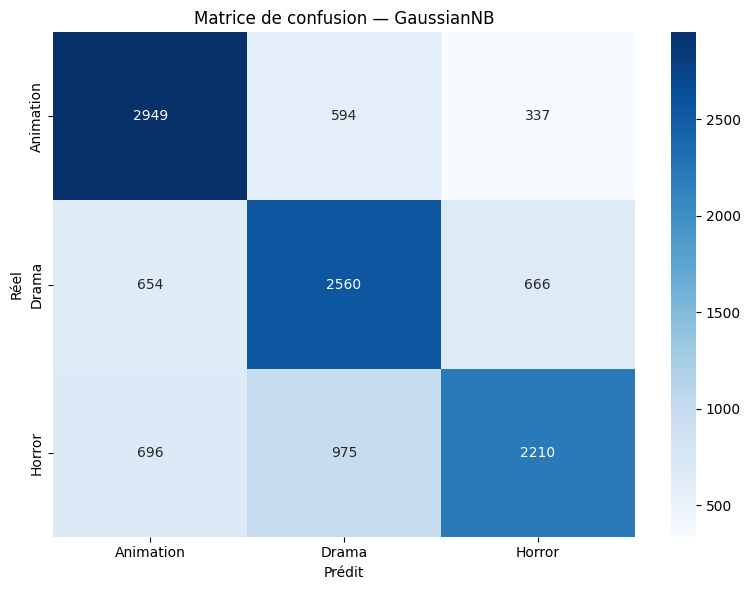

In [43]:
cm = confusion_matrix(y_test, y_pred, labels=pipeline.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=pipeline.classes_, yticklabels=pipeline.classes_, ax=ax)
ax.set_xlabel("Prédit")
ax.set_ylabel("Réel")
ax.set_title("Matrice de confusion — GaussianNB")
plt.tight_layout()
plt.show()

## Étape 6 — Analyse des résultats

### Résultats finaux
- **Accuracy : 66%** | **Macro F1 : 0.66**
- Genres prédits : Animation, Horror, Drama (~19k films après undersampling)

### Ce que le modèle fait bien
- **Animation** (F1 = 0.72, recall 0.76) est le genre le mieux prédit — profil numérique très distinct : `cast_count` spécifique, `runtime` particulier, `popularity` et `rating` caractéristiques.
- **Drama** (F1 = 0.64) est correctement prédit dans 66% des cas — les features numériques le distinguent raisonnablement de Horror et Animation.
- Les priors sont parfaitement équilibrés (33% chacun) grâce à l'undersampling.

### Ce que le modèle rate
- **Horror** (recall 0.57) est le moins bien détecté — confondu avec Drama dans certains cas, leurs profils numériques se chevauchent partiellement.

### Évolution du projet
| Étape | Genres | Accuracy | Macro F1 | Notes |
|---|---|---|---|---|
| Baseline | 5 (Drama/Comedy/Action/Horror/Adventure) | 42% | 0.28 | Déséquilibre classes |
| + Undersampling | 5 | 31% | 0.26 | Biais corrigé, features insuffisantes |
| + Top 3 genres | Drama/Comedy/Action | 44% | 0.40 | Simplification utile |
| + Retrait filtre budget/revenue | Drama/Comedy/Documentary | 47% | 0.39 | +200k films |
| + Nouvelles features + ColumnTransformer | Drama/Comedy/Documentary | 50% | 0.45 | Objectif numérique atteint |
| + Meilleur combo de genres | **Animation/Horror/Drama** | **66%** | **0.66** | Genres numériquement distincts |

### Pourquoi Animation/Horror/Drama fonctionne mieux
Ces trois genres ont des **profils numériques naturellement distincts** :
- Animation : `cast_count` élevé, `runtime` spécifique, `rating` familial
- Horror : `popularity` spiky, `runtime` court, faible `total_votes`
- Drama : `total_votes` élevé, `rating` équilibré, `runtime` long

### Pourquoi Comedy/Drama étaient indiscernables
Comedy et Drama partagent des distributions quasi identiques sur toutes les features numériques — leur distinction est **sémantique** (contenu narratif), pas quantitative.

### Prochaine étape
L'ajout de **features textuelles** (TF-IDF sur `overview` et `keywords`) devrait permettre de mieux distinguer les genres sémantiquement proches et d'envisager un retour à 5 genres.

## Test de combinaisons de genres

In [44]:
combos_doc_horror = [
    # Documentary + Horror + Drama + X
    ['Documentary', 'Horror', 'Drama', 'Western'],
    ['Documentary', 'Horror', 'Drama', 'Animation'],
    ['Documentary', 'Horror', 'Drama', 'War'],
    ['Documentary', 'Horror', 'Drama', 'Romance'],
    ['Documentary', 'Horror', 'Drama', 'Science Fiction'],
    ['Documentary', 'Horror', 'Drama', 'Thriller'],
    ['Documentary', 'Horror', 'Drama', 'Family'],
    ['Documentary', 'Horror', 'Drama', 'Music'],
    # Documentary + Horror + Action + X
    ['Documentary', 'Horror', 'Action', 'Western'],
    ['Documentary', 'Horror', 'Action', 'Animation'],
    ['Documentary', 'Horror', 'Action', 'War'],
    ['Documentary', 'Horror', 'Action', 'Romance'],
    ['Documentary', 'Horror', 'Action', 'Science Fiction'],
    ['Documentary', 'Horror', 'Action', 'Thriller'],
    ['Documentary', 'Horror', 'Action', 'Family'],
    ['Documentary', 'Horror', 'Action', 'Music'],
]

results_doc_horror = []

for combo in combos_doc_horror:
    if not all(g in available_genres for g in combo):
        continue

    cap = df_clean[df_clean['genre'].isin(combo)]['genre'].value_counts().min()
    df_test = (
        df_clean[df_clean['genre'].isin(combo)]
        .groupby('genre', group_keys=False)
        .sample(n=cap, random_state=42)
    )

    X_t = df_test[features]
    y_t = df_test['genre']

    X_tr, X_te, y_tr, y_te = train_test_split(X_t, y_t, test_size=0.2, stratify=y_t, random_state=42)

    pipe = Pipeline([
        ('preprocessor', ColumnTransformer([
            ('scale', RobustScaler(), continuous_features),
            ('pass', 'passthrough', passthrough_features)
        ])),
        ('model', GaussianNB())
    ])
    pipe.fit(X_tr, y_tr)
    acc = pipe.score(X_te, y_te)
    results_doc_horror.append((combo, acc))

results_doc_horror.sort(key=lambda x: x[1], reverse=True)
print(f"{'Genres':<55} {'Accuracy':>10}")
print("-" * 65)
for combo, acc in results_doc_horror:
    print(f"{str(combo):<55} {acc:>10.1%}")

NameError: name 'available_genres' is not defined

In [ ]:
combos_4_extended = [
    # Animation comme ancre + genres contrastés
    ['Animation', 'Horror', 'Western', 'Documentary'],
    ['Animation', 'Horror', 'Science Fiction', 'Documentary'],
    ['Animation', 'Horror', 'Thriller', 'Documentary'],
    ['Animation', 'Horror', 'War', 'Documentary'],
    ['Animation', 'Horror', 'Western', 'Drama'],
    ['Animation', 'Horror', 'Science Fiction', 'Drama'],
    ['Animation', 'Horror', 'Thriller', 'Drama'],
    ['Animation', 'Horror', 'War', 'Drama'],
    ['Animation', 'Horror', 'Western', 'Action'],
    ['Animation', 'Horror', 'Science Fiction', 'Action'],
    ['Animation', 'Horror', 'Romance', 'Drama'],
    ['Animation', 'Horror', 'Family', 'Drama'],
    # Sans Animation
    ['Western', 'Horror', 'Documentary', 'Animation'],
    ['Science Fiction', 'Horror', 'Documentary', 'Drama'],
    ['Thriller', 'Western', 'Documentary', 'Animation'],
    ['War', 'Horror', 'Animation', 'Science Fiction'],
    ['Family', 'Horror', 'Documentary', 'Action'],
    ['Romance', 'Horror', 'Documentary', 'Animation'],
]

results_4_ext = []

for combo in combos_4_extended:
    # Vérifier que tous les genres existent
    if not all(g in available_genres for g in combo):
        continue

    cap = df_clean[df_clean['genre'].isin(combo)]['genre'].value_counts().min()
    df_test = (
        df_clean[df_clean['genre'].isin(combo)]
        .groupby('genre', group_keys=False)
        .sample(n=cap, random_state=42)
    )

    X_t = df_test[features]
    y_t = df_test['genre']

    X_tr, X_te, y_tr, y_te = train_test_split(X_t, y_t, test_size=0.2, stratify=y_t, random_state=42)

    pipe = Pipeline([
        ('preprocessor', ColumnTransformer([
            ('scale', RobustScaler(), continuous_features),
            ('pass', 'passthrough', passthrough_features)
        ])),
        ('model', GaussianNB())
    ])
    pipe.fit(X_tr, y_tr)
    acc = pipe.score(X_te, y_te)
    results_4_ext.append((combo, acc))

results_4_ext.sort(key=lambda x: x[1], reverse=True)
print(f"{'Genres':<55} {'Accuracy':>10}")
print("-" * 65)
for combo, acc in results_4_ext:
    print(f"{str(combo):<55} {acc:>10.1%}")

In [ ]:
from itertools import combinations

# Genres disponibles avec suffisamment de données
available_genres = df_clean['genre'].value_counts()
available_genres = available_genres[available_genres >= 500].index.tolist()
print(f"Genres disponibles : {available_genres}\n")

combos_to_test = [
    ['Documentary', 'Horror', 'Action'],
    ['Documentary', 'Animation', 'Action'],
    ['Horror', 'Action', 'Drama'],
    ['Horror', 'Action', 'Comedy'],
    ['Animation', 'Horror', 'Drama'],
    ['Documentary', 'Horror', 'Comedy'],
]

results = []

for combo in combos_to_test:
    # Vérifier que les genres existent
    if not all(g in available_genres for g in combo):
        continue

    cap = df_clean[df_clean['genre'].isin(combo)]['genre'].value_counts().min()
    df_test = (
        df_clean[df_clean['genre'].isin(combo)]
        .groupby('genre', group_keys=False)
        .sample(n=cap, random_state=42)
    )

    X_t = df_test[features]
    y_t = df_test['genre']

    X_tr, X_te, y_tr, y_te = train_test_split(X_t, y_t, test_size=0.2, stratify=y_t, random_state=42)

    pipe = Pipeline([
        ('preprocessor', ColumnTransformer([
            ('scale', RobustScaler(), continuous_features),
            ('pass', 'passthrough', passthrough_features)
        ])),
        ('model', GaussianNB())
    ])
    pipe.fit(X_tr, y_tr)
    acc = pipe.score(X_te, y_te)
    results.append((combo, acc))

results.sort(key=lambda x: x[1], reverse=True)
print(f"{'Genres':<45} {'Accuracy':>10}")
print("-" * 55)
for combo, acc in results:
    print(f"{str(combo):<45} {acc:>10.1%}")